# A low-level Gaussian Process API

Built on one idea:

> **A GP prior is an `MvNormal`. Everything else is generic linear-Gaussian
> machinery that knows nothing about GPs.**

| Concept | What it actually is |
|---|---|
| GP prior | `pm.MvNormal(mu, K)`, `K = kernel(X)` |
| Partition (train / predict / inducing) | `pt.pack` + `pt.unpack` — a slice |
| Integrating the latent out | `pymc_extras.marginalize` |
| Posterior over the latent | `pymc_extras.conditional` |
| GP conditional mean | `project` |
| GP conditional covariance | `conditional_covariance` |
| Sparse / variational GP | `project` onto inducing inputs, stock ADVI guide |

The only new machinery is a **linear-Gaussian conjugacy rewrite**: for
`f ~ MvNormal(m, K)` and `y ~ Normal(g(f), s)` with `g` affine,

$$y \sim \mathcal{N}(Am + b,\; AKA^\top + S), \qquad
f \mid y \sim \mathcal{N}\big(m + (AK)^\top G^{-1} r,\; K - (AK)^\top G^{-1}(AK)\big)$$

with $G = AKA^\top + S$, $r = y - (Am+b)$. It registers into
`marginal_ir_rewrites_db`; `marginalize` and `conditional` then work unmodified.
It is not GP-specific — it covers regression coefficients and state-space
latents identically.

Because `g` is *any* affine function, "observed at a subset of the inputs" and
"projected from inducing points" are the same operation.

---

*Generated from `gp_api_build.py`. Edit that, regenerate, then run
`gp_api_execute.py`.*

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import pytensor.tensor as pt

import pymc_extras.gp as pgp

RNG = np.random.default_rng(0)
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

N_TRAIN = 60
X = np.linspace(0, 1, N_TRAIN)[:, None]
y = np.sin(6 * X.ravel()) + 0.2 * RNG.normal(size=N_TRAIN)
X_pred = np.linspace(-0.3, 1.3, 80)[:, None]

ETA_TRUE, LS_TRUE, SIGMA_TRUE = 1.7, 0.3, 0.2

## Kernels

Callable objects, not matrices: `k(X)` is the covariance, `k(X, Xs)` the
cross-covariance. Keeping the *function* is what lets a model be re-evaluated at
new inputs. They compose with `+` and `*` and scale by scalars, including model
random variables, which is how hyperpriors enter.

k(X)     -> (60, 60)
k(X, Xs) -> (60, 80)  (cross-covariance, rectangular)


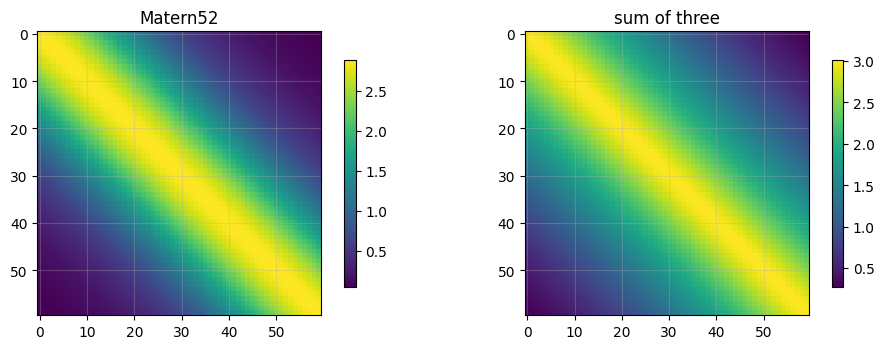

In [2]:
k = ETA_TRUE**2 * pgp.kernels.Matern52(ls=LS_TRUE)
print("k(X)     ->", k(X).eval().shape)
print("k(X, Xs) ->", k(X, X_pred).eval().shape, " (cross-covariance, rectangular)")

k_composite = (
    2.0 * pgp.kernels.ExpQuad(ls=np.array([0.5]))
    + pgp.kernels.Matern32(ls=0.2)
    + pgp.kernels.WhiteNoise(0.1)
)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, kern, name in zip(axes, [k, k_composite], ["Matern52", "sum of three"]):
    im = ax.imshow(kern(X).eval(), cmap="viridis")
    ax.set_title(name)
    fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## The prior, and partitioning

Define the prior jointly over every input set of interest, stacked with
`pt.pack`; `pt.unpack` splits any value sharing that leading axis.

`gp` is a single `MvNormal`, and "observed at the training points" is `f_train`,
a plain slice. Slicing is affine, which is all the marginalization needs.
Packing costs nothing: `pymc_extras.gp.rewrites` lifts the `Split` that
`pt.unpack` emits, so the unused partition never enters the covariance.

In [3]:
with pm.Model() as latent_model:
    ls = pm.InverseGamma("ls", alpha=3.0, beta=1.0)
    eta = pm.Exponential("eta", scale=1.0)
    sigma = pm.HalfNormal("sigma", sigma=1.0)

    Xs, shapes = pt.pack(X, X_pred, keep_axes=-1)
    gp = pgp.GP("gp", Xs, cov=eta**2 * pgp.kernels.Matern52(ls=ls))
    f_train, f_pred = pt.unpack(gp, shapes)

    pm.Normal("y", mu=f_train, sigma=sigma, observed=y)

print("gp      :", gp.type.shape)
print("f_train :", f_train.type.shape)
print("f_pred  :", f_pred.type.shape)
print("free_RVs:", [v.name for v in latent_model.free_RVs])

gp      : (140,)
f_train : (60,)
f_pred  : (80,)
free_RVs: ['ls', 'eta', 'sigma', 'gp']


## The building blocks

Two functions carry all the GP-specific content, and they are the *same formula*
seen twice. For a GP over inputs $Z$ and any new inputs $X_*$:

$$A_* = K_{*z}K_{zz}^{-1}, \qquad
\mathbb{E}[f_* \mid f_z] = A_* f_z, \qquad
\operatorname{Cov}[f_* \mid f_z] = K_{**} - A_*K_{z*}$$

* `project(gp, X_new)` builds $A_* f_z$ — the **conditional mean**.
* `conditional_covariance(gp, X_new)` builds $K_{**} - A_*K_{z*}$ — the
  **conditional covariance**.
* `prior_variance_correction(gp, X_new)` is its diagonal.

These were written for the sparse case and turned out to be the textbook GP
conditional. "Inducing points" and "prediction points" are not two ideas: both
are some other set of inputs you want the GP at, reached by the same linear map.

In [4]:
Z_demo = np.linspace(0, 1, 10)[:, None]
X_star = np.linspace(-0.1, 1.1, 7)[:, None]

with pm.Model():
    g_demo = pgp.GP("g", Z_demo, cov=k)
    proj = pgp.project(g_demo, X_star)
    C_full = pgp.conditional_covariance(g_demo, X_star)

f_z = RNG.normal(size=10)
Kzz = k(Z_demo).eval() + 1e-6 * np.eye(10)
Ksz = k(X_star, Z_demo).eval()

print(
    "project              == K_*z K_zz^-1 f_z :",
    np.allclose(proj.eval({g_demo: f_z}), Ksz @ np.linalg.solve(Kzz, f_z)),
)
print(
    "conditional_covariance == K_** - A K_z*  :",
    np.allclose(
        C_full.eval() - 1e-6 * np.eye(7),
        k(X_star).eval() - Ksz @ np.linalg.solve(Kzz, Ksz.T),
        atol=1e-8,
    ),
)

project              == K_*z K_zz^-1 f_z : True
conditional_covariance == K_** - A K_z*  : True


The full matrix rather than the diagonal is what makes draws *joint*, i.e.
actual smooth functions.

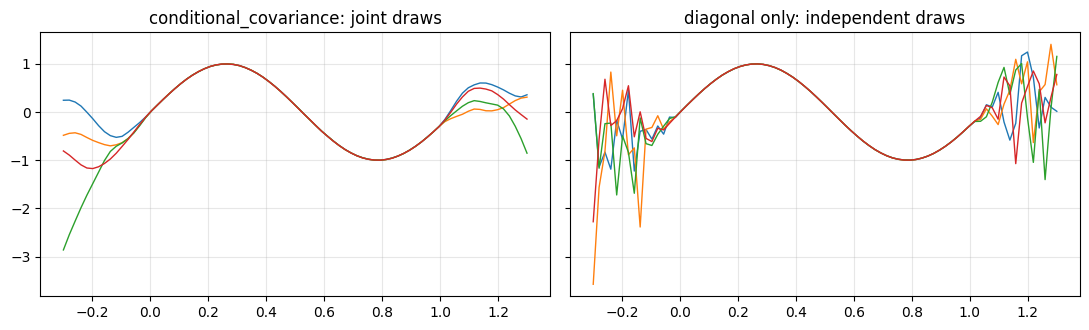

In [5]:
with pm.Model():
    g2 = pgp.GP("g2", X, cov=k)
    mu_j = pgp.project(g2, X_pred)
    C_j = pgp.conditional_covariance(g2, X_pred)
    d_j = pgp.prior_variance_correction(g2, X_pred)
    mu_v = mu_j.eval({g2: np.sin(6 * X.ravel())})
    C_v, d_v = C_j.eval(), d_j.eval()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
axes[0].plot(X_pred.ravel(), RNG.multivariate_normal(mu_v, C_v, size=4).T, lw=1)
axes[0].set_title("conditional_covariance: joint draws")
axes[1].plot(X_pred.ravel(), (mu_v + np.sqrt(d_v) * RNG.normal(size=(4, len(X_pred)))).T, lw=1)
axes[1].set_title("diagonal only: independent draws")
plt.tight_layout()
plt.show()

## A conjugate likelihood: marginalize, then condition

The latent integrates out in closed form, so NUTS samples 3 hyperparameters
instead of 3 + 140. `conditional` then returns a model in which `gp` is a free
RV whose distribution *is* the posterior, still symbolic in the hyperparameters,
so the prediction block comes back with it and no separate predictive formula is
needed.

In [6]:
marginal_model = pgp.marginalize(latent_model, ["gp"])
print("free_RVs before:", [v.name for v in latent_model.free_RVs])
print("free_RVs after :", [v.name for v in marginal_model.free_RVs])

with marginal_model:
    idata = pm.sample(draws=400, tune=400, chains=2, random_seed=0, progressbar=False)

print(az.summary(idata, var_names=["ls", "eta", "sigma"], round_to=3))
print("\ntrue: ls =", LS_TRUE, " eta =", ETA_TRUE, " sigma =", SIGMA_TRUE)
print(
    "\nsigma and ls are recovered; eta is weakly identified in a GP marginal"
    "\nlikelihood (it trades off against ls) and the Exponential(1) prior pulls"
    "\nit down. A property of the model, not of the machinery."
)

free_RVs before: ['ls', 'eta', 'sigma', 'gp']
free_RVs after : ['sigma', 'ls', 'eta']


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [sigma, ls, eta]


Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 87 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


        mean     sd  eti89_lb  eti89_ub  ess_bulk  ess_tail  r_hat  mcse_mean  \
ls     0.344  0.123     0.190     0.563   257.651   163.071  1.002      0.009   
eta    0.950  0.527     0.449     2.041   246.623   137.336  1.010      0.044   
sigma  0.165  0.018     0.140     0.195   437.696   470.906  1.002      0.001   

       mcse_sd  
ls       0.009  
eta      0.058  
sigma    0.001  

true: ls = 0.3  eta = 1.7  sigma = 0.2

sigma and ls are recovered; eta is weakly identified in a GP marginal
likelihood (it trades off against ls) and the Exponential(1) prior pulls
it down. A property of the model, not of the machinery.


free_RVs: ['eta', 'ls', 'sigma', 'gp']  <- gp is back


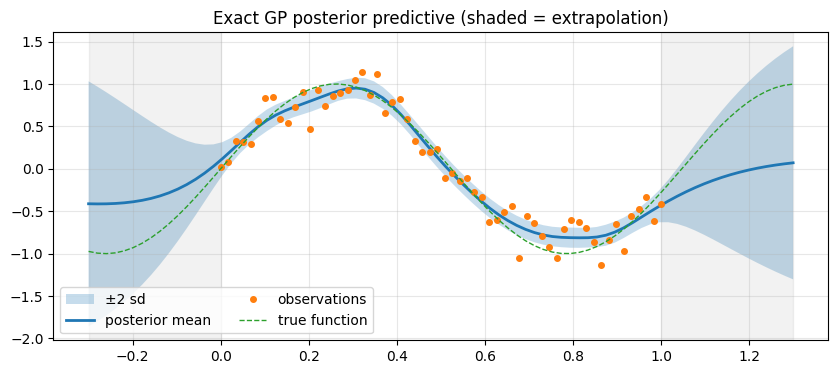

In [7]:
cond_model = pgp.conditional(marginal_model)
print("free_RVs:", [v.name for v in cond_model.free_RVs], " <- gp is back")

mu_sym, cov_sym = pgp.conditional_moments(cond_model)
_, mu_pred_sym = pt.unpack(mu_sym, shapes)
_, sd_pred_sym = pt.unpack(pt.sqrt(pt.diag(cov_sym)), shapes)
predictive = pgp.predictive_fn(cond_model, [mu_pred_sym, sd_pred_sym])

post = idata.posterior.to_dataset().stack(sample=("chain", "draw"))
means, sds = [], []
for i in range(0, post.sizes["sample"], 20):
    s = post.isel(sample=i)
    m_, sd_ = predictive(
        {
            "ls_log__": float(np.log(s["ls"])),
            "eta_log__": float(np.log(s["eta"])),
            "sigma_log__": float(np.log(s["sigma"])),
        }
    )
    means.append(m_)
    sds.append(sd_)

means, sds = np.array(means), np.array(sds)
mean_pred = means.mean(0)
sd_pred = np.sqrt(sds.mean(0) ** 2 + means.var(0))  # law of total variance

xg = X_pred.ravel()
fig, ax = plt.subplots()
ax.fill_between(xg, mean_pred - 2 * sd_pred, mean_pred + 2 * sd_pred, alpha=0.25, label="±2 sd")
ax.plot(xg, mean_pred, lw=2, label="posterior mean")
ax.plot(X.ravel(), y, "o", ms=4, label="observations")
ax.plot(xg, np.sin(6 * xg), ls="--", lw=1, label="true function")
ax.axvspan(-0.3, 0, color="k", alpha=0.05)
ax.axvspan(1.0, 1.3, color="k", alpha=0.05)
ax.set_title("Exact GP posterior predictive (shaded = extrapolation)")
ax.legend(loc="lower left", ncols=2)
plt.show()

## A non-conjugate likelihood: sample the latent, project to predict

With a Bernoulli likelihood the latent no longer integrates out and
`marginalize` declines rather than guessing, so it is sampled instead. The model
holds the training inputs only: rows that get sampled are dimensions the sampler
must explore, and prediction rows have no data to constrain them (packing 60 of
them into this problem drops min ESS from 482 to 4).

Prediction is `project` plus `conditional_covariance` afterwards, and wrapping
that in the *same* likelihood gives `y_new`. Both go on the model after fitting,
and `sample_vars` is what forces a redraw rather than echoing the trace.

In [8]:
X_b = np.linspace(0, 1, 40)[:, None]
p_true = 1 / (1 + np.exp(-3 * np.sin(6 * X_b.ravel())))
y_b = RNG.binomial(1, p_true)
X_b_pred = np.linspace(-0.2, 1.2, 60)[:, None]
k_b = 3.0**2 * pgp.kernels.Matern52(ls=0.25)

with pm.Model() as bern_model:
    gp_b = pgp.GP("gp", X_b, cov=k_b)  # training inputs only
    pm.Bernoulli("y", logit_p=gp_b, observed=y_b)

try:
    pgp.marginalize(bern_model, ["gp"])
except NotImplementedError as exc:
    print("marginalize declines:", str(exc)[:70], "...")

with bern_model:
    idata_b = pm.sample(draws=500, tune=1000, chains=2, random_seed=0, progressbar=False)
print("max r_hat:", float(np.nanmax(az.rhat(idata_b, var_names=["gp"])["gp"].to_numpy())))

Initializing NUTS using jitter+adapt_diag...


marginalize declines: Cannot marginalize gp with distribution MvNormalRV{name='multivariate_ ...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [gp]


Sampling 2 chains for 1_000 tune and 500 draw iterations (2_000 + 1_000 draws total) took 79 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


max r_hat: 1.010532686110251


Sampling: [f_pred, y_new]


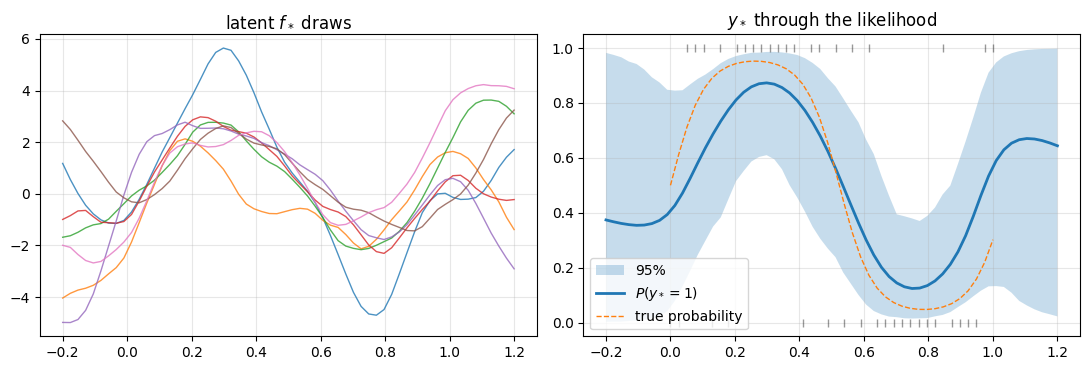

In [9]:
with bern_model:
    pm.MvNormal(
        "f_pred",
        mu=pgp.project(gp_b, X_b_pred),
        cov=pgp.conditional_covariance(gp_b, X_b_pred),
    )
    pm.Bernoulli("y_new", logit_p=bern_model["f_pred"])
    pp = pm.sample_posterior_predictive(
        idata_b, sample_vars=["f_pred", "y_new"], random_seed=0, progressbar=False
    )

f_draws = pp.posterior_predictive["f_pred"].to_numpy().reshape(-1, len(X_b_pred))
p_draws = 1 / (1 + np.exp(-f_draws))

xb = X_b_pred.ravel()
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(xb, f_draws[::150].T, lw=1, alpha=0.8)
axes[0].set_title("latent $f_*$ draws")
axes[1].fill_between(xb, *np.percentile(p_draws, [2.5, 97.5], axis=0), alpha=0.25, label="95%")
axes[1].plot(xb, p_draws.mean(0), lw=2, label="$P(y_*=1)$")
axes[1].plot(X_b.ravel(), p_true, ls="--", lw=1, label="true probability")
axes[1].plot(X_b.ravel(), y_b, "|", ms=6, alpha=0.4, color="k")
axes[1].set_ylim(-0.05, 1.05)
axes[1].set_title("$y_*$ through the likelihood")
axes[1].legend(loc="lower left")
plt.tight_layout()
plt.show()

## A non-conjugate likelihood: fit it variationally

Sampling the latent degrades as it grows: 120 training points already gives
`r_hat = 2.5`. Putting the prior on a few inducing inputs and `project`ing onto
the data shrinks the latent to those inducing values, which is also the
construction to reach for with many observations.

No SVGP-specific code exists. The ELBO

$$\mathrm{ELBO} = \mathbb{E}_{q(u)}\big[\log p(y \mid Au)\big] - \mathrm{KL}\big(q(u)\,\|\,p(u)\big)$$

is what `E_q[log p(y,u) - log q(u)]` already computes when `p(u)` is the model
and `q(u)` the guide, so the KL term is never implemented. Prediction is the
same three lines as above, because `Trainer.sample_posterior` returns draws that
`sample_posterior_predictive` consumes directly.

/home/ricardo/Documents/.pymc-extras-worktree2/.venv/lib64/python3.13/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/ricardo/Documents/.pymc-extras-worktree2/.venv/lib64/python3.13/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/ricardo/Documents/.pymc-extras-worktree2/.venv/lib64/python3.13/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/ricardo/Documents/.pymc-extras-worktree2/.venv/lib64/python3.13/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/ricardo/Documents/.pymc-extras-worktree2/.venv/lib64/python3.13/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/ricardo/Documents/.pymc-extras-worktree2/.venv/lib64/python3.13/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/ricardo/Documents/.pymc-extras-worktree2/.venv/lib64/python3.13/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/ricardo/Documents/.pymc-extras-worktree2/.venv/lib64/python3.13/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

latent dim: (15,) | sample_posterior -> DataTree


Sampling: [f_pred, y_new]


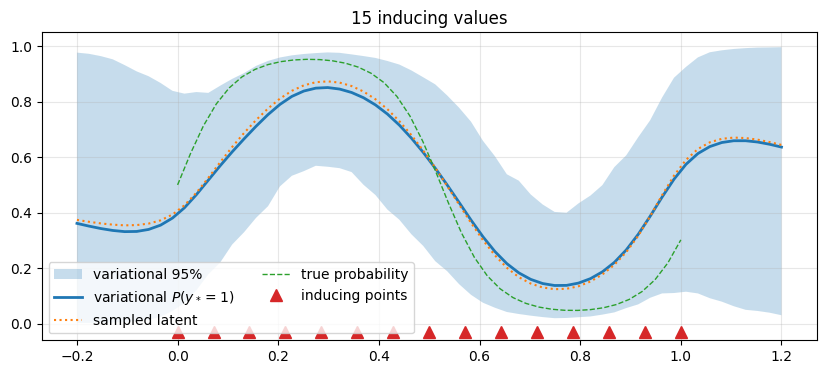

In [10]:
from pymc_extras.inference.advi import AutoMultivariateNormal, Trainer

Z_b = np.linspace(0, 1, 15)[:, None]

with pm.Model() as svgp_model:
    u_b = pgp.GP("u", Z_b, cov=k_b)
    pm.Bernoulli("y", logit_p=pgp.project(u_b, X_b), observed=y_b)

trainer = Trainer(guide=AutoMultivariateNormal, model=svgp_model, n_particles=32, random_seed=0)
trainer.fit(3000)
idata_vi = trainer.sample_posterior(draws=1000, random_seed=0)
print("latent dim:", u_b.type.shape, "| sample_posterior ->", type(idata_vi).__name__)

with svgp_model:
    pm.MvNormal(
        "f_pred",
        mu=pgp.project(u_b, X_b_pred),
        cov=pgp.conditional_covariance(u_b, X_b_pred),
    )
    pm.Bernoulli("y_new", logit_p=svgp_model["f_pred"])
    pp_vi = pm.sample_posterior_predictive(
        idata_vi, sample_vars=["f_pred", "y_new"], random_seed=0, progressbar=False
    )

p_vi = 1 / (1 + np.exp(-pp_vi.posterior_predictive["f_pred"].to_numpy().reshape(-1, len(X_b_pred))))

fig, ax = plt.subplots()
ax.fill_between(xb, *np.percentile(p_vi, [2.5, 97.5], axis=0), alpha=0.25, label="variational 95%")
ax.plot(xb, p_vi.mean(0), lw=2, label="variational $P(y_*=1)$")
ax.plot(xb, p_draws.mean(0), lw=1.5, ls=":", label="sampled latent")
ax.plot(X_b.ravel(), p_true, ls="--", lw=1, label="true probability")
ax.plot(Z_b.ravel(), np.full(len(Z_b), -0.03), "^", ms=8, label="inducing points")
ax.set_ylim(-0.06, 1.05)
ax.set_title("15 inducing values")
ax.legend(loc="lower left", ncols=2)
plt.show()

## What is missing

1. **Woodbury / structured covariance.** $AKA^\top$ is densified, so the sparse
   construction is correct but scales $O(n^{2.3})$ rather than $O(nm^2)$. The
   main blocker, and the same work item as low-rank ADVI guides.
2. **Non-centered parameterization.** `GP` has no `parameterization=`, which is
   what caps the sampled-latent path at around a hundred observations.

Shallow by construction: kernel coverage, no mean-function namespace, no
multi-output or Kronecker structure, no `predict_f` / `predict_y` wrappers.

### Design notes

* `A` is **never materialized**. The linear map is applied with
  `vectorize_graph`, preserving structure, so a partition stays a slice and
  PyTensor can push it into the kernel graph. `pt.unpack` emits a `Split`, which
  nothing lifts, so `pymc_extras.gp.rewrites` turns a partly-unused `Split` back
  into `Subtensor`s and lets the existing machinery do the rest.
* Affineness is checked by a conservative op whitelist; anything unrecognized
  declines cleanly rather than producing a wrong logp.
* `project` and `conditional_covariance` are the GP conditional, which is why
  the sampled and variational fits share their prediction code verbatim.